#  Введение

**Контекст:**
Книжное издательство реализует продукцию через два канала:
- маркетплейс
- собственный интернет-магазин
    
**Цель:**
Оценить эффективность двух каналов продаж (маркетплейс и собственный интернет-магазин), 
выявить ключевые драйверы выручки и маржинальности, а также выявить точки роста бизнеса.

Объект анализа: заказ, товар / SKU, поджанр / жанр, канал.

Период: 2025.

Ограничение: это synthetic data, но данные приближены к реальному бизнесу.

# Исследование и проверка данных

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from babel.numbers import format_decimal, format_currency, \
    format_compact_decimal, format_compact_currency

from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style="ticks", context="talk")

OUTPUT_DIR = "../data"

In [2]:
df_orders = pd.read_csv(f'{OUTPUT_DIR}/orders.csv',
                        parse_dates=['order_date'],
                        usecols=[
                            'order_id', 'order_date', 'channel', 'customer_id',
                            'order_status', 'basket_size', 
                            'order_quantity_requested','order_quantity_fulfilled',
                            'net_revenue', 'commission_fee', 'shipping_cost',
                            'ad_spend', 'product_cost', 'margin',
                            'gmv_after_discount'
                        ])
print(f'Заказы: {df_orders.shape}')

df_order_items = pd.read_csv(f'{OUTPUT_DIR}/order_items.csv',)
print(f'Состав заказа: {df_order_items.shape}')

df_products = pd.read_csv(f'{OUTPUT_DIR}/products.csv',
                          usecols=[
                              'product_id', 'product_name', 'genre',
                              'subgenre', 'rating', 'is_new_release',
                              'is_series', 'launch_date'
                          ])
print(f'Товары: {df_products.shape}')

df_customers = pd.read_csv(f'{OUTPUT_DIR}/customers.csv',
                           parse_dates=["join_date"])

print(f'Покупатели: {df_customers.shape}')

Заказы: (1000050, 15)
Состав заказа: (1707328, 21)
Товары: (12000, 8)
Покупатели: (640000, 7)


## Заказы

In [3]:
df_orders.head()

,order_id,order_date,channel,customer_id,order_status,basket_size,order_quantity_requested,order_quantity_fulfilled,gmv_after_discount,commission_fee,shipping_cost,ad_spend,product_cost,net_revenue,margin
0,MP_ORD000000001,2025-01-01,marketplace,MPC0144910,completed,1,1,1,682.85,109.26,141.08,30.55,341.75,682.85,60.21
1,MP_ORD000000002,2025-01-01,marketplace,MPC0006073,completed,3,4,4,4977.49,925.49,128.07,0.00,1667.79,4977.49,2256.14
2,MP_ORD000000003,2025-01-01,marketplace,MPC0098169,completed,5,9,9,5585.88,948.63,227.36,602.39,2191.15,5585.88,1616.35
3,MP_ORD000000004,2025-01-01,marketplace,MPC0394113,completed,1,1,1,458.35,82.50,157.49,0.00,143.84,458.35,74.52
4,MP_ORD000000005,2025-01-01,marketplace,MPC0057191,completed,3,5,5,4842.66,967.31,214.78,321.23,2213.74,4842.66,1125.60


In [4]:
df_orders.describe()

,order_date,basket_size,order_quantity_requested,order_quantity_fulfilled,gmv_after_discount,commission_fee,shipping_cost,ad_spend,product_cost,net_revenue,margin
count,1000050,1000050.00,1000050.00,1000050.00,1000050.00,1000050.00,1000050.00,1000050.00,1000050.00,1000050.00,1000050.00
mean,2025-07-12 05:49:28.922754048,1.71,2.42,2.42,2328.95,272.44,180.24,48.02,931.88,2239.16,806.57
min,2025-01-01 00:00:00,1.00,1.00,1.00,83.67,0.00,79.02,0.00,37.64,0.00,-17605.38
25%,2025-04-11 00:00:00,1.00,1.00,1.00,830.72,0.00,141.43,0.00,301.33,780.74,157.44
50%,2025-07-16 00:00:00,1.00,2.00,2.00,1544.78,154.87,172.19,0.00,565.41,1480.96,465.68
75%,2025-10-16 00:00:00,2.00,3.00,3.00,3012.55,363.31,210.14,46.81,1161.60,2908.62,1083.11
max,2025-12-31 00:00:00,6.00,19.00,19.00,43074.98,8216.04,549.87,3842.78,23399.00,43074.98,19989.28
std,NaN,1.06,1.88,1.88,2305.53,380.15,53.63,114.09,1069.64,2269.11,1147.72


In [5]:
df_orders.iloc[:, 1:].describe(include=["object"])

,channel,customer_id,order_status
count,1000050,1000050,1000050
unique,2,384901,3
top,marketplace,MPC0053923,completed
freq,720036,95,937812


In [6]:
df_orders['order_status'].value_counts()

order_status
completed    937812
partial       38820
returned      23418
Name: count, dtype: int64

## Позиции заказа

In [7]:
df_order_items.head()

,order_item_id,order_id,product_id,quantity_requested,quantity_fulfilled,quantity_returned,quantity_unfulfilled,unit_price,discount_rate,gross_revenue_before_discount,discount_amount,gmv_after_discount,lost_revenue_unfulfilled,refund_amount,commission_fee,shipping_cost_allocated,ad_spend_allocated,product_cost,net_revenue,margin,item_status
0,MA_ITEM0000000001,MP_ORD000000001,BK008855,1,1,0,0,853.56,0.20,853.56,170.71,682.85,0.00,0.00,109.26,141.08,30.55,341.75,682.85,60.21,completed
1,MA_ITEM0000000002,MP_ORD000000002,BK008092,1,1,0,0,1011.70,0.00,1011.70,0.00,1011.70,0.00,0.00,171.99,32.02,0.00,426.37,1011.70,381.32,completed
2,MA_ITEM0000000003,MP_ORD000000002,BK001622,1,1,0,0,645.17,0.15,645.17,96.78,548.39,0.00,0.00,104.19,32.02,0.00,205.84,548.39,206.34,completed
3,MA_ITEM0000000004,MP_ORD000000002,BK003142,2,2,0,0,1708.70,0.00,3417.40,0.00,3417.40,0.00,0.00,649.31,64.03,0.00,1035.58,3417.40,1668.48,completed
4,MA_ITEM0000000005,MP_ORD000000003,BK008335,2,2,0,0,1171.93,0.00,2343.86,0.00,2343.86,0.00,0.00,375.02,50.53,245.45,888.04,2343.86,784.82,completed


In [8]:
df_order_items.describe()

,quantity_requested,quantity_fulfilled,quantity_returned,quantity_unfulfilled,unit_price,discount_rate,gross_revenue_before_discount,discount_amount,gmv_after_discount,lost_revenue_unfulfilled,refund_amount,commission_fee,shipping_cost_allocated,ad_spend_allocated,product_cost,net_revenue,margin
count,1707328.00,1707328.00,1707328.00,1707328.00,1707328.00,1707328.00,1707328.00,1707328.00,1707328.00,1707328.00,1707328.00,1707328.00,1707328.00,1707328.00,1707328.00,1707328.00,1707328.00
mean,1.42,1.42,0.05,0.00,1008.01,0.04,1427.24,63.08,1364.16,0.00,52.59,159.58,105.58,28.13,545.84,1311.57,472.44
std,0.83,0.83,0.31,0.00,707.07,0.08,1402.55,160.23,1351.06,0.00,386.78,245.28,55.36,69.98,684.98,1346.74,666.38
min,1.00,1.00,0.00,0.00,118.20,0.00,118.20,0.00,82.86,0.00,0.00,0.00,11.71,0.00,37.64,0.00,-17605.38
25%,1.00,1.00,0.00,0.00,546.13,0.00,635.26,0.00,604.79,0.00,0.00,0.00,59.35,0.00,212.78,561.42,144.39
50%,1.00,1.00,0.00,0.00,856.34,0.00,1022.72,0.00,983.94,0.00,0.00,99.79,96.19,0.00,351.50,950.46,330.63
75%,2.00,2.00,0.00,0.00,1229.39,0.10,1695.22,61.18,1607.18,0.00,0.00,208.87,144.05,29.00,588.56,1550.98,635.66
max,6.00,6.00,6.00,0.00,5395.61,0.30,31390.38,7230.46,31390.38,0.00,26610.05,6127.28,373.39,2801.58,19534.92,31390.38,14898.20


In [9]:
df_order_items.iloc[:, 1:].describe(include=['object'])

,order_id,product_id,item_status
count,1707328,1707328,1707328
unique,1000050,11791,2
top,ON_ORD000812937,BK011590,completed
freq,6,34314,1643590


In [10]:
df_order_items['item_status'].value_counts()

item_status
completed    1643590
returned       63738
Name: count, dtype: int64

## Товары

In [11]:
df_products.head()

,product_id,product_name,genre,subgenre,rating,is_new_release,is_series,launch_date
0,BK000001,Psychology_BK000001,Non-Fiction,Psychology,4.30,False,False,2022-07-24
1,BK000002,Activity Books_BK000002,Children,Activity Books,4.33,False,False,2022-12-05
2,BK000003,Romance_BK000003,Fiction,Romance,4.15,False,False,2022-01-31
3,BK000004,Middle Grade_BK000004,Children,Middle Grade,4.21,False,True,2023-07-27
4,BK000005,Comics_BK000005,Comics & Manga,Comics,4.84,False,False,2022-12-11


In [12]:
df_products.iloc[:, 1:].describe(include=['object'])

,product_name,genre,subgenre,launch_date
count,12000,12000,12000,12000
unique,12000,7,34,1458
top,Psychology_BK000001,Fiction,Romance,2024-12-16
freq,1,3202,583,19


## Покупатели

In [13]:
df_customers.head()

,customer_id,customer_domain,age,gender,region,join_date,loyalty_member
0,MPC0000001,marketplace,39,F,Татарстан,2022-02-17,False
1,MPC0000002,marketplace,44,F,Москва,2023-07-19,False
2,MPC0000003,marketplace,29,F,Москва,2022-05-24,False
3,MPC0000004,marketplace,46,M,Московская область,2024-11-15,False
4,MPC0000005,marketplace,53,M,Нижегородская область,2024-05-16,False


In [14]:
df_customers.describe()

,age,join_date
count,640000.00,640000
mean,39.71,2023-12-31 05:40:06.735000320
min,18.00,2022-01-01 00:00:00
25%,29.00,2022-12-31 00:00:00
50%,38.00,2023-12-31 00:00:00
75%,49.00,2024-12-30 00:00:00
max,70.00,2025-12-30 00:00:00
std,13.35,NaN


In [15]:
df_customers.iloc[:, 1:].describe(include=['object'])

,customer_domain,gender,region
count,640000,640000,640000
unique,2,2,10
top,marketplace,F,Москва
freq,420000,396965,153269


## Проверка дубликатов

In [16]:
print("Duplicate orders:", df_orders["order_id"].duplicated().sum())
print("Duplicate items:", df_order_items[["order_id", "order_item_id"]].duplicated().sum())
print("Duplicate products:", df_products["product_id"].duplicated().sum())
print("Duplicate customers:", df_customers["customer_id"].duplicated().sum())

Duplicate orders: 0
Duplicate items: 0
Duplicate products: 0
Duplicate customers: 0


## Поиск пропущенных связей

In [17]:
missing_orders = df_order_items.loc[
    ~df_order_items["order_id"].isin(df_orders["order_id"])
]
print("Missing orders:", len(missing_orders))

missing_products = df_order_items.loc[
    ~df_order_items["product_id"].isin(df_products["product_id"])
]
print("Missing products:", len(missing_products))

missing_customers = df_orders.loc[
    ~df_orders["customer_id"].isin(df_customers["customer_id"])
]
print("Missing customers:", len(missing_customers))

Missing orders: 0
Missing products: 0
Missing customers: 0


**Вывод**: данны консистентны

# Feature engineering

In [353]:
df_orders["month"] = df_orders["order_date"].dt.to_period("M")
df_orders["day"] = df_orders["order_date"].dt.to_period("D")
df_orders["quarter"] = df_orders["order_date"].dt.to_period("Q")
df_orders["margin_ratio"] = df_orders["margin"].div(df_orders["net_revenue"],
                                                    fill_value=0)
df_orders['is_loss'] = df_orders['margin'] < 0

df_orders.head()

,order_id,order_date,channel,customer_id,order_status,basket_size,order_quantity_requested,order_quantity_fulfilled,gmv_after_discount,commission_fee,shipping_cost,ad_spend,product_cost,net_revenue,margin,month,day,week,quarter,margin_ratio,is_loss
0,MP_ORD000000001,2025-01-01,marketplace,MPC0144910,completed,1,1,1,682.85,109.26,141.08,30.55,341.75,682.85,60.21,2025-01,2025-01-01,2024-12-30/2025-01-05,2025Q1,0.09,False
1,MP_ORD000000002,2025-01-01,marketplace,MPC0006073,completed,3,4,4,4977.49,925.49,128.07,0.00,1667.79,4977.49,2256.14,2025-01,2025-01-01,2024-12-30/2025-01-05,2025Q1,0.45,False
2,MP_ORD000000003,2025-01-01,marketplace,MPC0098169,completed,5,9,9,5585.88,948.63,227.36,602.39,2191.15,5585.88,1616.35,2025-01,2025-01-01,2024-12-30/2025-01-05,2025Q1,0.29,False
3,MP_ORD000000004,2025-01-01,marketplace,MPC0394113,completed,1,1,1,458.35,82.50,157.49,0.00,143.84,458.35,74.52,2025-01,2025-01-01,2024-12-30/2025-01-05,2025Q1,0.16,False
4,MP_ORD000000005,2025-01-01,marketplace,MPC0057191,completed,3,5,5,4842.66,967.31,214.78,321.23,2213.74,4842.66,1125.60,2025-01,2025-01-01,2024-12-30/2025-01-05,2025Q1,0.23,False


## Объединение датасетов

In [161]:
df = (df_orders.merge(df_order_items, on="order_id", suffixes=(None, '_item'))
               .merge(df_products, on="product_id", suffixes=(None, '_product'))
               .merge(df_customers, on="customer_id", suffixes=(None, '_customer')))

print(df_order_items.shape)
print(df.shape)

(1707328, 21)
(1707328, 53)


# Overview

Основная задача: Оценить общий масштаб и структуру бизнеса

Определить:
- какой объём продаж?
- как распределяются заказы?
- есть ли сезонность?
- насколько стабильна маржинальность?


In [20]:
def print_currency(title: str,
                   value: float,
                   max_len=45,
                   max_value_len=20,
                   currency='RUB',
                   locale='ru_RU'):
    print(f"{title:<{max_len}} {format_currency(value, currency, locale=locale):>{max_value_len}}")


def print_compact_currency(title: str,
                           value: float,
                           max_len=45,
                           currency='RUB',
                           locale='ru_RU'):
    print(f"{title:<{max_len}} {format_compact_currency(value, currency, locale=locale)}")


def print_decimal(title: str,
                  value: float | str,
                  max_len=45,
                  max_value_len=20,
                  locale='ru_RU'):
    print(f"{title:<{max_len}} {format_decimal(value, locale=locale):>{max_value_len}}")


def print_compact_decimal(title: str,
                          value: float | str,
                          max_len=45,
                          locale='ru_RU'):
    print(f"{title:<{max_len}} {format_compact_decimal(value, locale=locale)}")

## Масштаб бизнеса

In [169]:
print("\n=== 🛒Заказы ===")
total_orders = df_orders["order_id"].nunique()
print_decimal("Общее количество заказов", total_orders)

status_counts = df_orders['order_status'].value_counts()
print("В разрезе статуса выполнения:")
for status, count in status_counts.items():    
    print_decimal(f"  • {status:}", count)
    
avg_basket_size = df_orders["basket_size"].mean()
print_decimal("Cреднее число уникальных позиций в заказе", avg_basket_size)
avg_items_per_order = df_orders["order_quantity_requested"].mean()
print_decimal("Среднее количество товаров в заказе", avg_items_per_order)

print("\n===📦Товары ===")
total_quantity = df_order_items[df_order_items["item_status"] ==
                                'completed']["quantity_fulfilled"].sum()
total_refunds = df_order_items[df_order_items["item_status"] ==
                                'returned']["quantity_fulfilled"].sum()

units_metrics =  [
    ("Общее количество проданных единиц", total_quantity),
    ("Общее количество возвратов", total_refunds)    
]

for name, value in units_metrics:
    print_decimal(name, value)

print("\n===💰Финансы ===")
# Gross Merchandise Value
gmv = df_orders["gmv_after_discount"].sum()
total_revenue = df_orders["net_revenue"].sum()
profit = df_orders["margin"].sum()
discount_amount = df_order_items[df_order_items["item_status"] ==
                     'completed']["discount_amount"].sum()
refunds = df_order_items[df_order_items["item_status"] ==
                     'returned']["gmv_after_discount"].sum()
avg_check = df_orders["net_revenue"].mean()
fin_metrics =  [
    ("Сумма оплаченных заказов (+возвраты)", gmv),
    ("Выручка", total_revenue),
    ("Маржинальная прибыль", profit),
    ("Сумма скидок", discount_amount),
    ("Стоимость возвратов", refunds),
    ("Средний чек", avg_check),
]

for name, value in fin_metrics:
    print_currency(name, value)


=== 🛒Заказы ===
Общее количество заказов                                 1 000 050
В разрезе статуса выполнения:
  • completed                                              937 812
  • partial                                                 38 820
  • returned                                                23 418
Cреднее число уникальных позиций в заказе                    1,707
Среднее количество товаров в заказе                          2,421

===📦Товары ===
Общее количество проданных единиц                        2 331 800
Общее количество возвратов                                  88 996

===💰Финансы ===
Сумма оплаченных заказов (+возвраты)            2 329 067 528,03 ₽
Выручка                                         2 239 274 607,36 ₽
Маржинальная прибыль                              806 612 979,67 ₽
Сумма скидок                                      102 160 718,12 ₽
Стоимость возвратов                                89 792 920,67 ₽
Средний чек                                      

In [202]:
df_completed_orders = df_orders[df_orders['order_status'] != 'returned']
daily_orders = (df_completed_orders
                         .groupby("day")
                         .agg(revenue=("net_revenue", "sum"),
                              margin=("margin", "sum"),
                              orders=("order_id", "count"))
                         .reset_index())
print_currency("Средняя дневная выручка", daily_orders["revenue"].mean())
print_currency("Средняя дневная прибыль", daily_orders["margin"].mean())
print_decimal("Среднее количество заказов в день", round(daily_orders["orders"].mean()))


monthly_orders = (df_completed_orders
                           .groupby("month")
                           .agg(revenue=("net_revenue", "sum"),
                                margin=("margin", "sum"),
                                orders=("order_id", "count"))
                           .reset_index())
print()
print_currency("Средняя месячная выручка", monthly_orders["revenue"].mean())
print_currency("Средняя месячная прибыль", monthly_orders["margin"].mean())
print_decimal("Среднее количество заказов в месяц", round(monthly_orders["orders"].mean()))


quarter_orders = (df_completed_orders
                          .groupby("quarter")
                          .agg(revenue=("net_revenue", "sum"),
                               margin=("margin", "sum"),
                               orders=("order_id", "count"))
                          .reset_index())
print()
print_currency("Средняя квартальная выручка", quarter_orders["revenue"].mean())
print_currency("Средняя квартальная прибыль", quarter_orders["margin"].mean())
print_decimal("Среднее количество заказов в квартал", round(quarter_orders["orders"].mean()))


Средняя дневная выручка                             6 134 998,92 ₽
Средняя дневная прибыль                             2 261 272,69 ₽
Среднее количество заказов в день                            2 676

Средняя месячная выручка                          186 606 217,28 ₽
Средняя месячная прибыль                           68 780 377,70 ₽
Среднее количество заказов в месяц                          81 386

Средняя квартальная выручка                       559 818 651,84 ₽
Средняя квартальная прибыль                       206 341 133,11 ₽
Среднее количество заказов в квартал                       244 158


## Динамика продаж

Как меняются продажи и прибыль во времени? Есть ли сезонность?

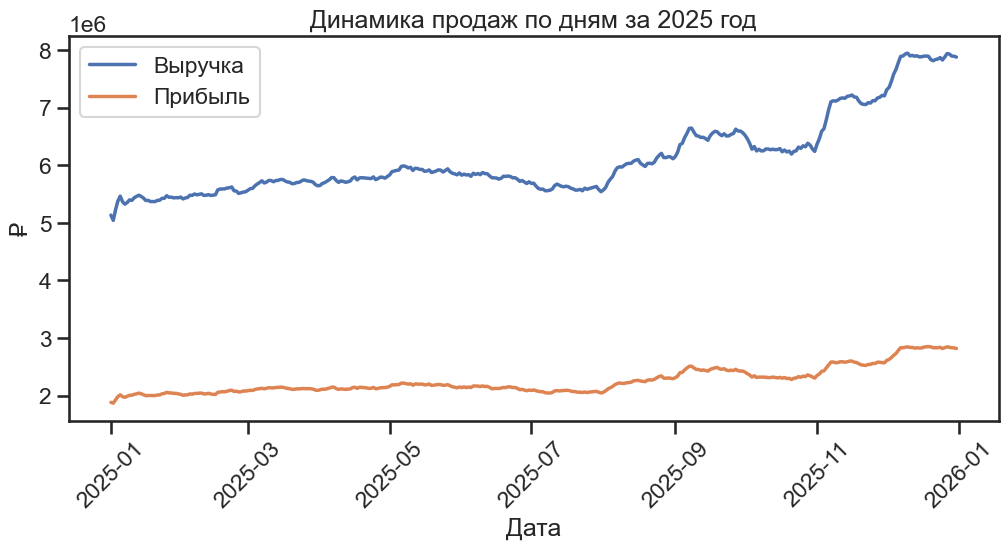

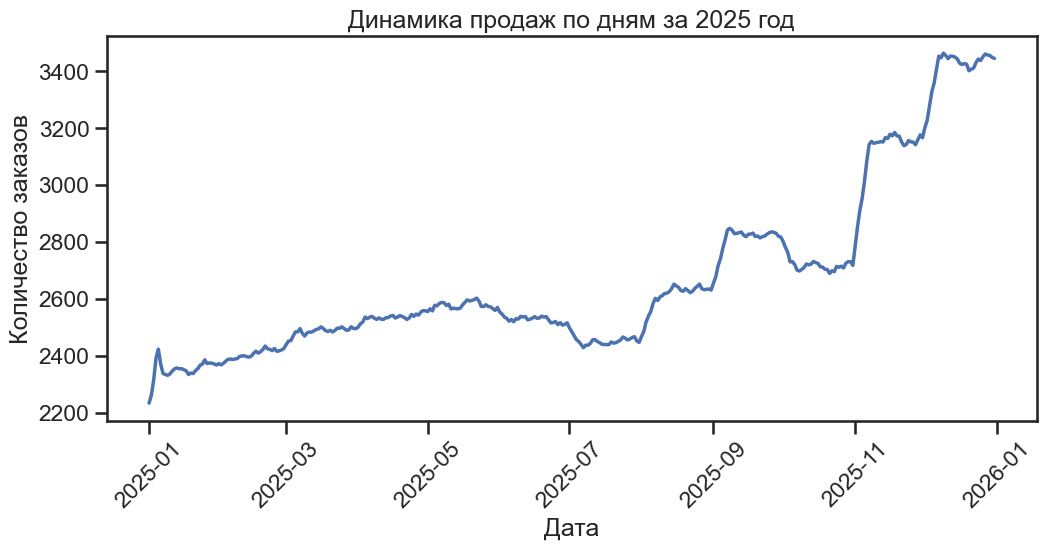

In [199]:
def plot_time_series_with_rolling(data,
                                  date_column,
                                  value_columns,
                                  value_labels,
                                  metric_label,
                                  title,
                                  days_window=7):
    columns = value_columns + [date_column]
    plot_data = data[columns].copy()
    plot_data[date_column] = plot_data[date_column].dt.to_timestamp()
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    for i, column in enumerate(value_columns):
        rolling_column = f'rolling_{column}'
        plot_data[rolling_column] = (plot_data[column]
                                         .rolling(days_window, min_periods=1)
                                         .mean())          
        sns.lineplot(data=plot_data,
                     x=date_column,
                     y=rolling_column,
                     linewidth=2.5,
                     label=value_labels[i],
                     ax=ax)

    plt.title(title)
    plt.xlabel("Дата")
    plt.ylabel(metric_label)
    plt.xticks(rotation=45)
    plt.show()


plot_time_series_with_rolling(daily_orders,
                              "day",
                              value_columns=["revenue", "margin"],
                              value_labels=['Выручка', 'Прибыль'],
                              metric_label="₽",
                              title="Динамика продаж по дням за 2025 год")


plot_time_series_with_rolling(daily_orders,
                              "day",
                              value_columns=["orders"],
                              value_labels=[''],
                              metric_label="Количество заказов",
                              title="Динамика продаж по дням за 2025 год")

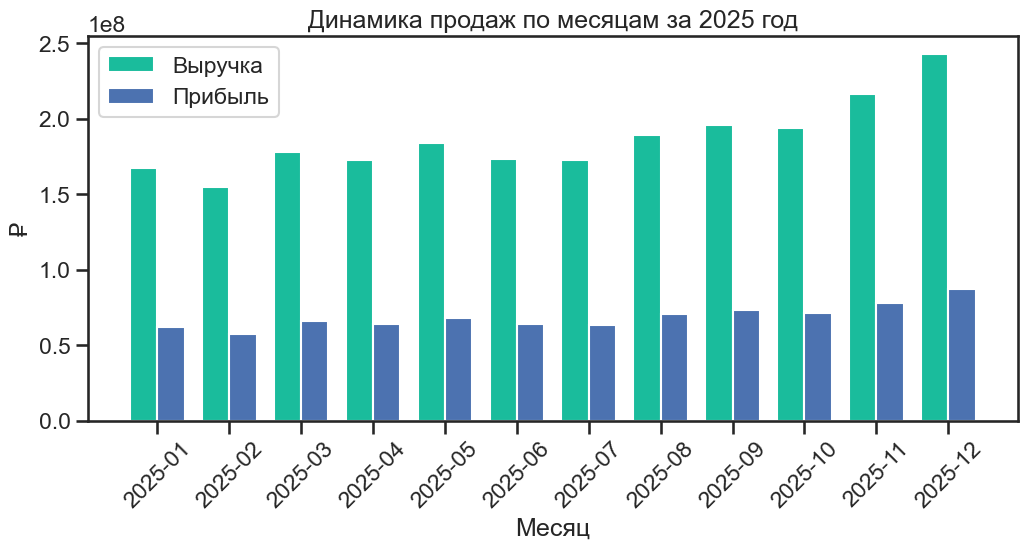

In [200]:
x = np.arange(len(monthly_orders))
width = 0.38

plt.figure(figsize=(12, 5))

plt.bar(
    x - width/2,
    monthly_orders['revenue'],
    width=width,
    label='Выручка',
    color='#1abc9c',
)
plt.bar(
    x + width/2,
    monthly_orders['margin'],
    width=width,
    label='Прибыль'
)

plt.title("Динамика продаж по месяцам за 2025 год")
plt.xlabel("Месяц")
plt.ylabel("₽")
plt.xticks(x, monthly_orders['month'], rotation=45)
plt.legend()

plt.show()

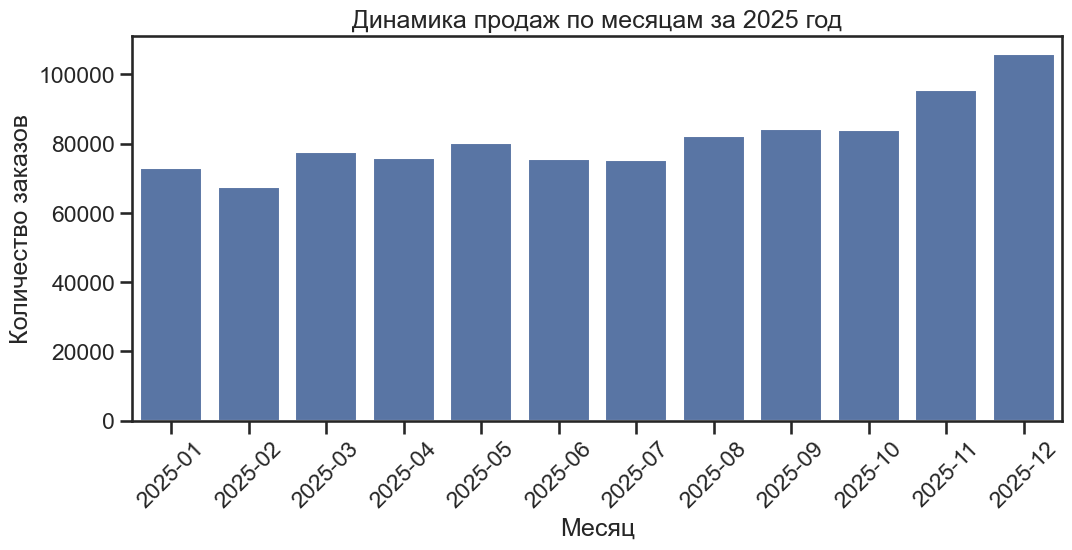

In [201]:
plt.figure(figsize=(12, 5))

sns.barplot(x='month',
            y='orders',
            data=monthly_orders)

plt.title("Динамика продаж по месяцам за 2025 год")
plt.xlabel("Месяц")
plt.ylabel("Количество заказов")
plt.xticks(rotation=45)

plt.show()

- Наблюдаются выраженные пики и спады. 
- Пики продаж приходятся на сентябрь, а самый выраженный пик - на ноябрь-декабрь
- Спад приходится на летние месяцы
- Рост заказов не всегда сопровождается пропорциональным ростом прибыли.

**Выводы:**
- Бизнес подвержен сезонности. Но для полной картины необходим анализ динамики за несколько лет, чтобы подвтвердить сезонность.
- Важно отдельно анализировать прибыль, а не только выручку  

## Распределение заказов

- Как распределяются заказы по размеру и стоимости?
Есть ли перекосы?
- Как размер заказа влияет на прибыль?

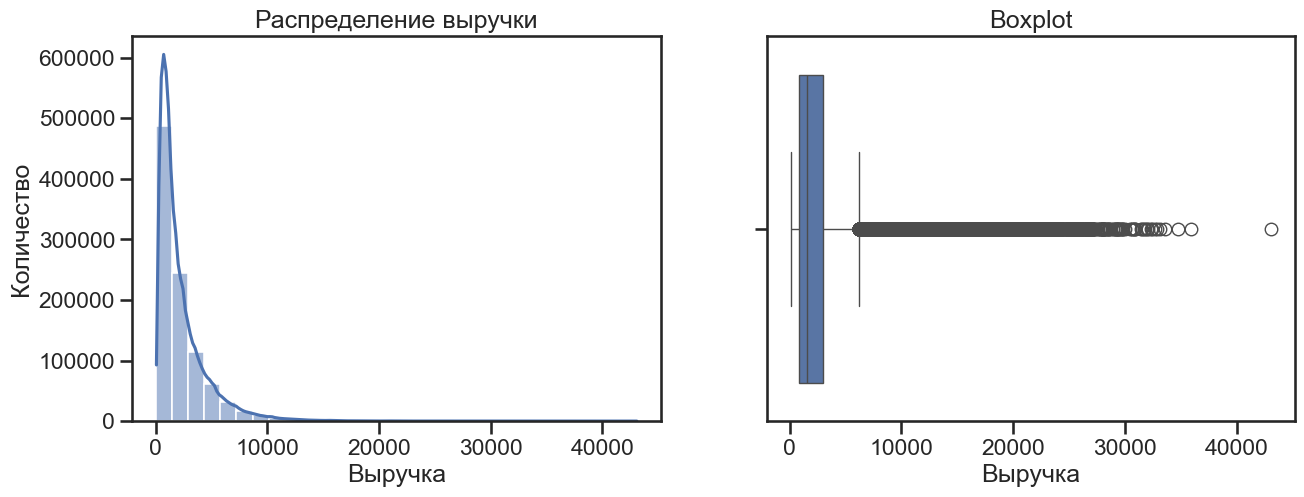

In [303]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 5))

sns.histplot(df_completed_orders['net_revenue'], kde=True, bins=30, ax=ax1)

ax1.set_title("Распределение выручки")
ax1.set_xlabel("Выручка")
ax1.set_ylabel('Количество')

sns.boxplot(data=df_completed_orders['net_revenue'], ax=ax2, orient='h')
ax2.set_title('Boxplot')
ax2.set_xlabel('Выручка')

plt.show()

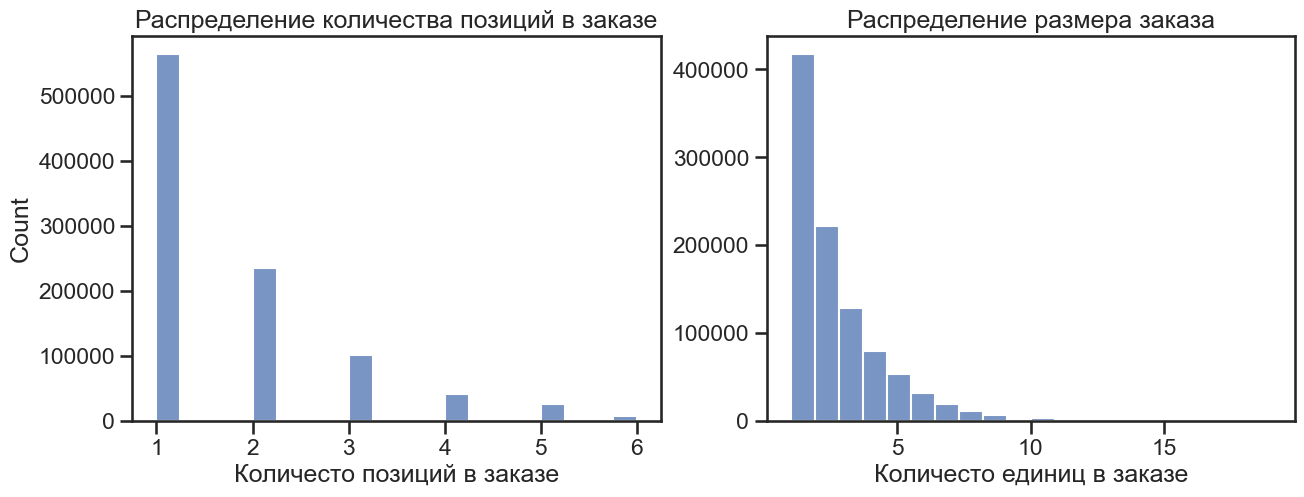

In [261]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 5))

sns.histplot(df_completed_orders['basket_size'], bins=20, ax=ax1)
ax1.set_title("Распределение количества позиций в заказе")
ax1.set_xlabel("Количесто позиций в заказе")

sns.histplot(df_completed_orders['order_quantity_fulfilled'], bins=20, ax=ax2)
ax2.set_title("Распределение размера заказа")
ax2.set_xlabel('Количесто единиц в заказе')
ax2.set_ylabel('')

plt.show()

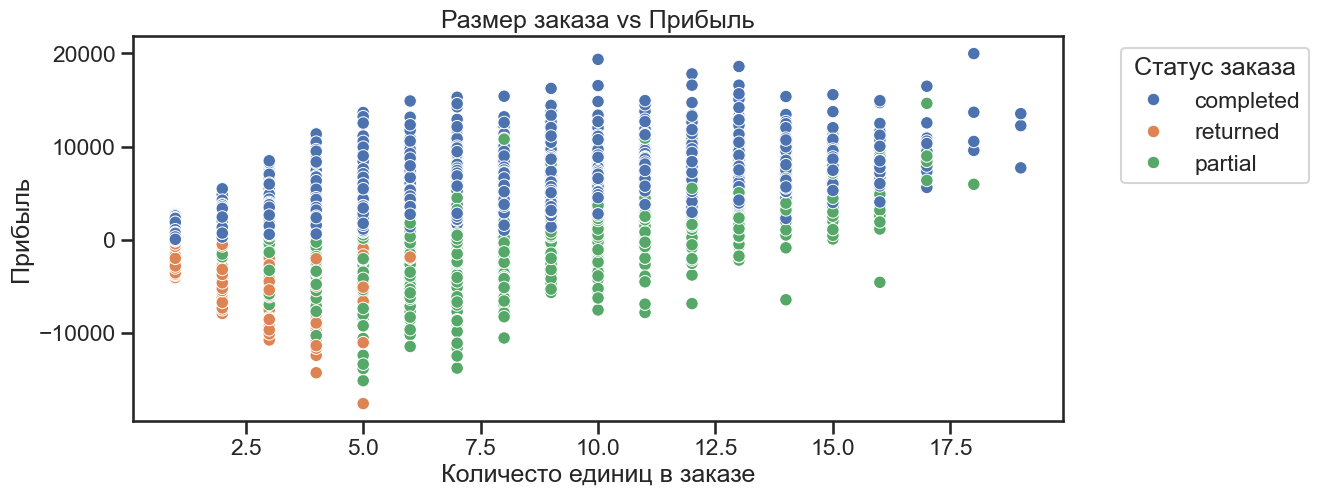

In [415]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.scatterplot(
    x='order_quantity_fulfilled',
    y='margin',
    hue="order_status",
    data=df_orders,
    ax=ax,   
)
ax.legend(title='Статус заказа', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_title("Размер заказа vs Прибыль")
ax.set_xlabel('Количесто единиц в заказе')
ax.set_ylabel('Прибыль')
plt.show()

**Выводы**
- Распределение заказов смещено в сторону небольших заказов, но при этом имеет "длинный хвост" более крупных заказов
- Маленькие заказы чаще убыточны, крупные заказы более устойчивы по прибыли
- Т.к. преобладают маленькие заказы, то это несет риск для маржинальности (в силу фиксированных затрат на заказ).
- Рост среднего чека - это один из ключевых рычагов повышения прибыльности.

## Распределение прибыли

Как распределена прибыль по заказам? Есть ли убыточные заказы?

In [389]:
# Проверка заказов на убыточность и распределение прибыли
status_mapping = {
    'completed': 'Выполнен',
    'partial': 'Частично выполнен',
    'returned': 'Возврат'
}

agg_config = {
    'orders': 'count',
    'mean': 'mean',
    'median': 'median',
    'p10': lambda x: x.quantile(0.10),
    'p25': lambda x: x.quantile(0.10),
    'p75': lambda x: x.quantile(0.10),
    'p90': lambda x: x.quantile(0.90),
    'share_loss': lambda x: (x < 0).mean() * 100,
}

rename_config = {
    'orders': 'Кол-во заказов',
    'mean': 'Средняя прибыль',
    'median': 'Медиана',
    'p10': 'P10',
    'p25': 'P25',
    'p75': 'P75',
    'p90': 'P90',
    'share_loss': 'Доля убыточных, %'
}

summary = (df_orders.groupby('order_status')['margin']
                   .agg(**agg_config)
                   .rename(columns=rename_config, index=status_mapping)
                   .rename_axis('Статус заказа'))

summary

,Кол-во заказов,Средняя прибыль,Медиана,P10,P25,P75,P90,"Доля убыточных, %"
Статус заказа,,,,,,,,
Выполнен,937812,863.45,492.82,37.82,37.82,37.82,2146.68,6.33
Частично выполнен,38820,402.04,162.84,-849.49,-849.49,-849.49,2130.24,41.47
Возврат,23418,-800.73,-547.65,-1603.75,-1603.75,-1603.75,-293.66,100.00


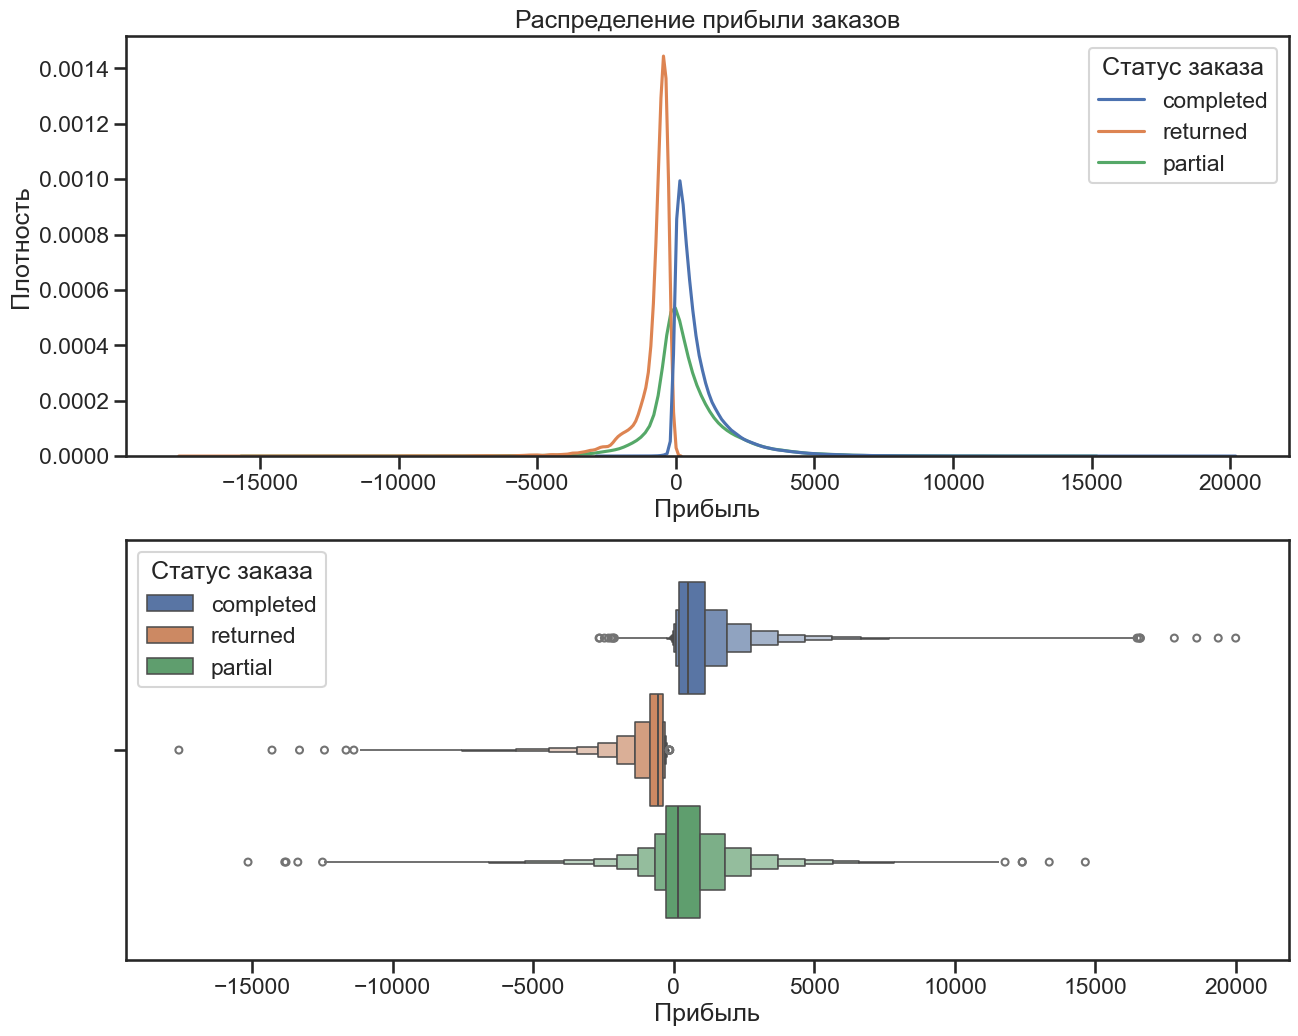

In [390]:
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(15, 12))

sns.kdeplot(data=df_orders,
            x="margin",
            hue="order_status",
            common_norm=False,
            ax=ax1)
ax1.set_title("Распределение прибыли заказов")
ax1.set_xlabel("Прибыль")
ax1.set_ylabel('Плотность')
ax1.get_legend().set_title('Статус заказа')

sns.boxenplot(data=df_orders, x="margin", hue="order_status", ax=ax2)
ax2.set_xlabel('Прибыль')
ax2.get_legend().set_title('Статус заказа')
plt.show()

**Выводы**
- Часть заказов имеет отрицательную маржу. В первую очередь это частичные и полные возвраты.
- 6% выполненных заказов имеет отрицательную маржу
- Бизнес может расти по выручке, но терять деньги на части операций. Необходим анализ unit-экономики.



## Общая структура выручки затрат

Из чего складывается экономика заказа?

In [468]:
costs = {
    'Прибыль': df_orders['margin'].sum(),
    'Себестоимость': df_orders['product_cost'].sum(),
    'Доставка': df_orders['shipping_cost'].sum(),
    'Комиссия': df_orders['commission_fee'].sum(),
    'Маркетинг': df_orders['ad_spend'].sum()
}

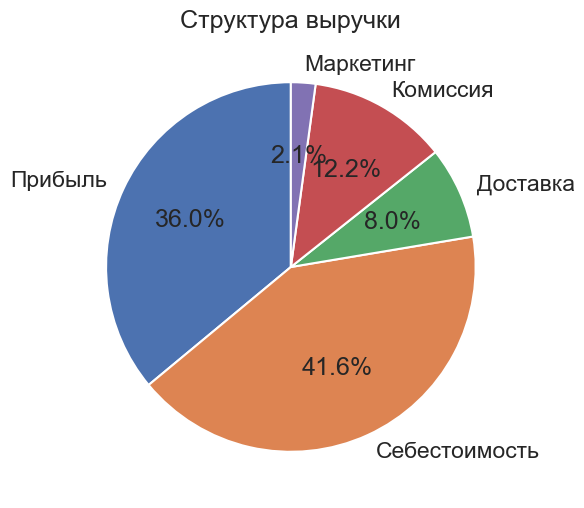

In [469]:
values = list(costs.values())
labels = list(costs.keys())

plt.figure(figsize=(6, 6))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Структура выручки')
plt.show()

**Выводы:**
- Основные затраты приходятся на: себестоимость, комиссию, логистику
- Для роста прибыли важно управлять структурой затрат, а не только выручкой.

## Выводы

- Бизнес демонстрирует выраженную сезонность, с пиками продаж в определённые месяцы. Это требует адаптации ассортимента и маркетинга
- Распределение прибыли асимметрично.
- Значительная часть заказов имеет небольшую корзину (1–2 товара). При этом часть заказов может быть убыточной из-за низкого среднего чека.
- Потери происходят не только из-за цен и затрат, но и из-за операционных проблем - возвраты.

# Сравнение каналов продажи

Как каналы отличаются?

Проверим:
- Из чего состоит выручка
- Какая доля от общего объема


## Масштаб бизнеса

Как каналы отличаются по масштабу бизнеса?
Каков вклад каналов в общий объем продаж?

In [459]:
channel_mapping = {
    'marketplace': 'Маркетплейс',
    'online_store': 'Онлайн-магазин'
}

df_channel_summary = (df_orders
                        .groupby('channel')
                        .agg({
                            'order_id': 'count',
                            'net_revenue': 'sum',
                            'margin': 'sum',
                            'order_quantity_fulfilled': 'sum'
                        }).rename(columns={
                            'order_id': 'Кол-во заказов',
                            'order_quantity_fulfilled': 'Размер заказа',
                            'margin': 'Прибыль',
                            'net_revenue': 'Выручка'
                        }, index=channel_mapping))

df_channel_summary

,Кол-во заказов,Выручка,Прибыль,Размер заказа
channel,,,,
Маркетплейс,720036,1440922785.08,394364338.33,1588000
Онлайн-магазин,280014,798351822.28,412248641.34,832796


In [467]:
df_channel_summary.div(df_channel_summary.sum())

,Кол-во заказов,Выручка,Прибыль,Размер заказа
channel,,,,
Маркетплейс,0.72,0.64,0.49,0.66
Онлайн-магазин,0.28,0.36,0.51,0.34


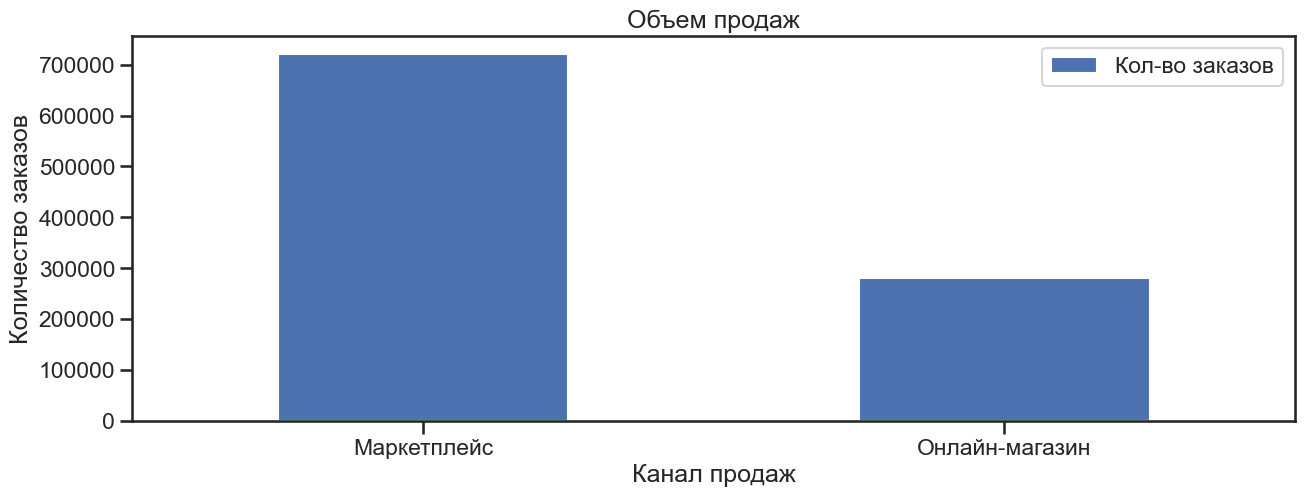

In [455]:
ax = df_channel_summary[['Кол-во заказов']].plot(kind='bar',
                                                 figsize=(15, 5))

ax.set_title('Объем продаж')
ax.set_xlabel('Канал продаж')
ax.set_ylabel('Количество заказов')
plt.xticks(rotation=0)
plt.show()

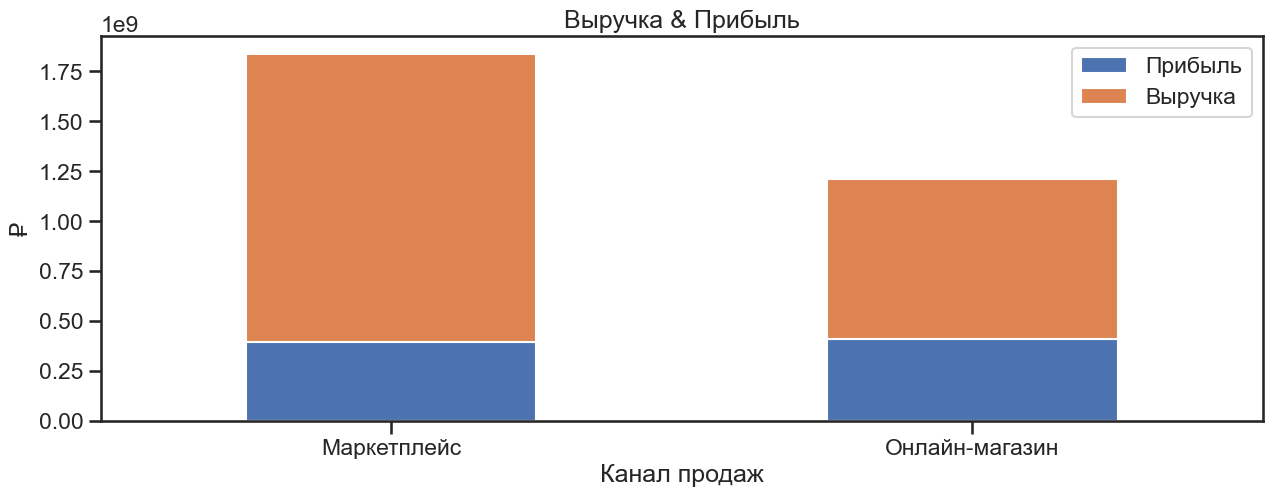

In [457]:
ax = df_channel_summary[['Прибыль', 'Выручка']].plot(kind='bar',
                                                     figsize=(15, 5),
                                                     stacked=True)

ax.set_title('Выручка & Прибыль')
ax.set_xlabel('Канал продаж')
ax.set_ylabel('₽')
ax.legend(title='Статус заказа')
ax.legend(bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.show()

**Вывод:**
- Маркетплейс существенно доминирует по объему продаж (72%). По сути это канал масштаба.
- При этом оба канала дают примерно равный размер прибыли: 49% маркетплейс, 51% онлайн-магазин

## Структура выручки

Из чего состоит выручка? Каковые основные затраты в разрезе каналов?

In [476]:
df_cost = (df_orders[df_orders['order_status'] != 'returned']
               .groupby('channel')[['product_cost', 'commission_fee', 'shipping_cost', 'ad_spend', 'margin']]
               .sum()
               .rename(columns={
                                'product_cost': 'Себестоимость (COGS)',
                                'commission_fee': 'Комиссия',
                                'shipping_cost': 'Доставка',
                                'ad_spend': 'Маркетинг',
                                'margin': 'Прибыль'
                            }, index=channel_mapping))

df_cost_pct = df_cost.div(df_cost.sum(axis=1), axis=0) * 100
df_cost_pct

,Себестоимость (COGS),Комиссия,Доставка,Маркетинг,Прибыль
channel,,,,,
Маркетплейс,41.64,18.91,7.87,3.13,28.45
Онлайн-магазин,39.80,0.00,7.91,0.26,52.03


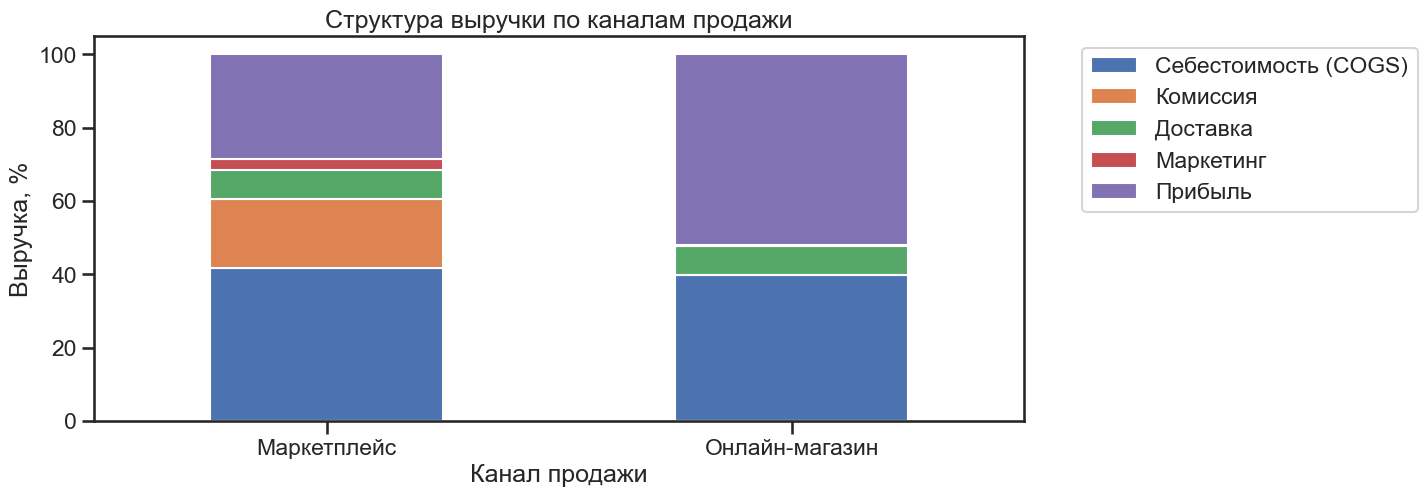

In [477]:
ax = df_cost_pct.plot(kind='bar', figsize=(12, 5), stacked=True)

ax.set_ylabel('Выручка, %')
ax.set_xlabel('Канал продажи')
ax.set_title('Структура выручки по каналам продажи')
ax.legend(bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.show()

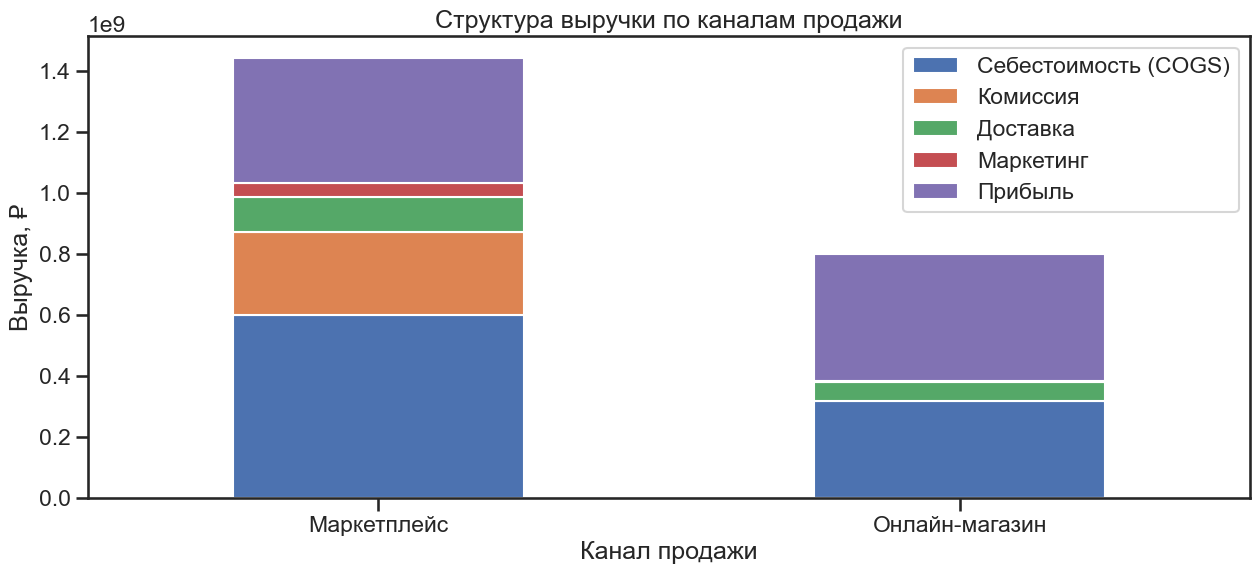

In [473]:
ax = df_cost.plot(kind='bar', figsize=(15, 6), stacked=True)

ax.set_ylabel('Выручка, ₽')
ax.set_xlabel('Канал продажи')
ax.set_title('Структура выручки по каналам продажи')
ax.legend(bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.show()

**Вывод**: 
- На маркетплейсе высокая комиссия - съедает 19% выручки
- В онлайн-магазине прибыль выше
- Доставка съедает 8% выручки

## Структура заказов по статусам

Где больше заказов и какие статусы дают объём?

In [474]:
status_mapping = {
    'completed': 'Выполнен',
    'partial': 'Частично выполнен',
    'returned': 'Возврат'
}

df_status = (df_orders.groupby(['channel', 'order_status'])
                      .size()
                      .unstack(fill_value=0)
                      .rename(columns=status_mapping, index=channel_mapping))
df_status_pct = df_status.div(df_status.sum(axis=1), axis=0)
df_status_pct

order_status,Выполнен,Частично выполнен,Возврат
channel,,,
Маркетплейс,0.93,0.04,0.03
Онлайн-магазин,0.95,0.04,0.01


In [475]:
df_status_global_pct = df_status / df_status.values.sum()
df_status_global_pct

order_status,Выполнен,Частично выполнен,Возврат
channel,,,
Маркетплейс,0.67,0.03,0.02
Онлайн-магазин,0.26,0.01,0.00


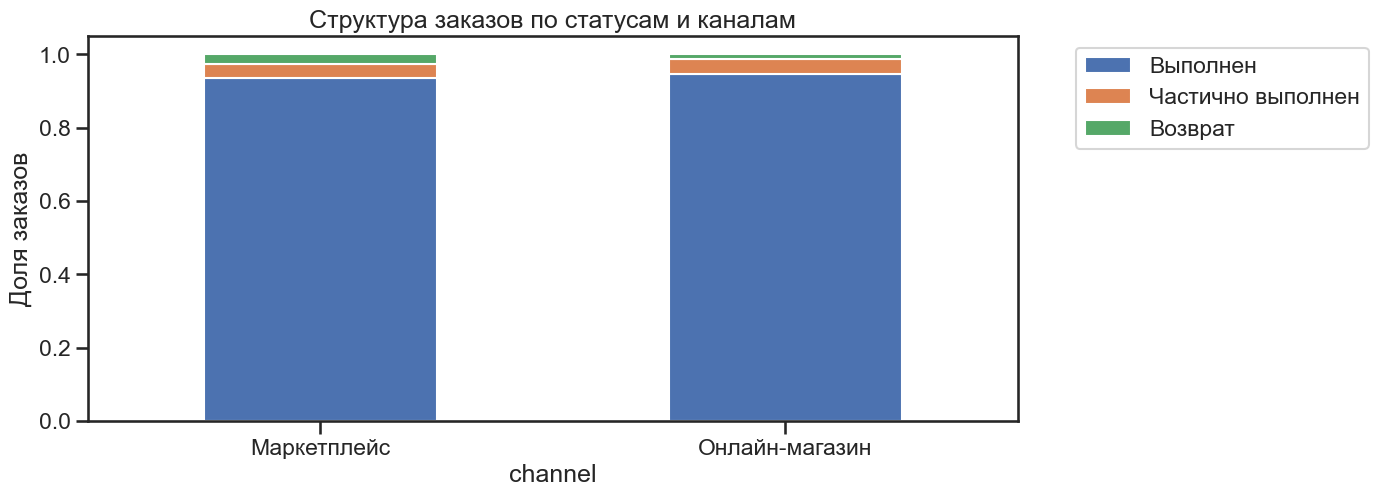

In [478]:
ax = df_status_pct.plot(kind='bar', figsize=(12, 5), stacked=True)

ax.set_ylabel('Доля заказов')
ax.set_title('Структура заказов по статусам и каналам')
ax.legend(title='Статус заказа')
ax.legend(bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.show()

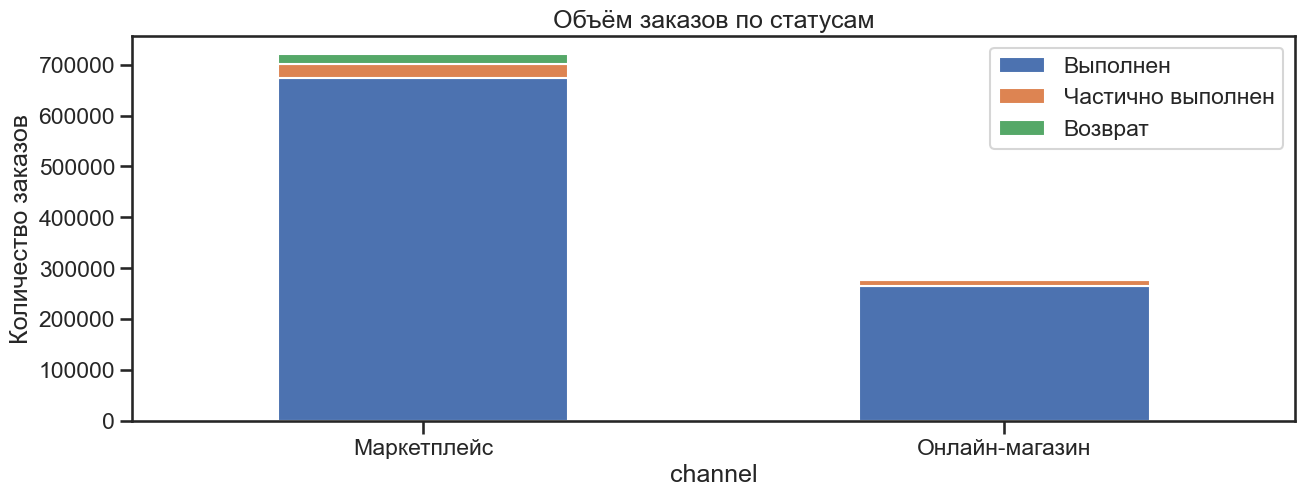

In [142]:
ax = df_status.plot(kind='bar', figsize=(15, 5), stacked=True)

ax.set_ylabel('Количество заказов')
ax.set_title('Объём заказов по статусам')
ax.legend(title='Статус заказа')
ax.legend(bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.show()

**Выводы:**
- На маркетплейсе выше доля возвратов

## Выводы

- Маркетплейс = масштаб + высокая комиссия + ниже маржа
- Собственный магазин = выше маржа + меньший объем продаж
- Основные драйверы различий:
  - комиссия
  - возвраты

# Финальные выводы

**Основные выводы**

1. Маркетплейс обеспечивает объем, но уступает по маржинальности.
2. Собственный магазин более прибыльный, но зависит от маркетинговых затрат.
3. Дешевые товары и высокие скидки снижают прибыльность.
4. Возвраты и недопоставки создают значительные потери.
5. Сезонность существенно влияет на спрос.

**Рекомендации**

- оптимизировать ценовую политику
- снижать возвраты
- фокусироваться на прибыльных категориях
- развивать собственный канал продаж